# Local neurotransmitter fingerprinting

In this tutorial, you will explore the local neurotransmitter fingerprinting (LNTF) functionalities of Lacuna using the CLI.

**What you'll learn**:

- Fetch the neurotransmitter PET atlas
- Compute per-target neurotransmitter density scores within a lesion
- Filter by neurotransmitter system presets
- Obtain parcel-level NT scores

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/06-local-neurotransmitter-fingerprinting.ipynb)

## Colab

Note: Colab provides limited computational resources. While these tutorials are designed to operate within those constraints, some Lacuna functionality cannot be fully demonstrated in this environment and requires access to higher-performance computing infrastructure.

Ignore this if you run this notebook locally.

## Setup

In [1]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

/usr/bin/pip:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import load_entry_point


  Cloning https://github.com/m-petersen/lacuna to /tmp/pip-req-build-56_kpx2l
  Running command git clone -q https://github.com/m-petersen/lacuna /tmp/pip-req-build-56_kpx2l


  Installing build dependencies ... -

 \

 |

...

 \ done


    Preparing wheel metadata ... -

 \ done


 \

 done
  Created wheel for UNKNOWN: filename=UNKNOWN-0.0.1.dev473-py3-none-any.whl size=1882 sha256=ea3c20280d8faf8c64bc3702a44a265198b7532cfc8ad28a609e602ff0bcb57c
  Stored in directory: /tmp/pip-ephem-wheel-cache-1n8_zc6g/wheels/66/aa/65/f42f78f57264024515cfdc1f33d42209046549b961eba82016
Successfully built UNKNOWN


Get the tutorial data.

In [65]:
# Get tutorial data
!lacuna tutorial /tmp/tutorial_bids --force


Setting up tutorial data at: /tmp/tutorial_bids
✓ Tutorial data copied to: /tmp/tutorial_bids


## Fetch neurotransmitter atlas

Local neurotransmitter fingerprinting requires a neurotransmitter PET atlas: a collection of PET receptor/transporter density maps from normative cohorts. Lacuna downloads representative maps from [NiSpace-data](https://github.com/LeonDLotter/NiSpace-data) — one recommended map per target — at a pinned commit, with SHA-256 verification.

`lacuna fetch ntatlas` downloads, z-scores, and saves a ready-to-use atlas in a single step. The output directory contains the prepared atlas (manifest + per-target NIfTIs) and is consumed directly by `lacuna run lntf`.

*Note on the cerebellum:* in most PET maps the cerebellum (or a cerebellar grey-matter sub-region) is used as the kinetic-modelling reference — non-specific tracer binding there is divided out of every voxel, so the cerebellum's own values become uninterpretable and are masked out. Expect zero / NaN cerebellar values in the downloaded maps.


In [64]:
!lacuna fetch ntatlas \
    --output-dir /tmp/ntatlas_data --force

Fetching neurotransmitter PET maps...
  Source: https://github.com/LeonDLotter/NiSpace-data
  Commit: a772c410f76dbbd022a3f5239e40176ff6f930c7


✓ Neurotransmitter atlas fetch complete!
  Files: 22
  Duration: 2.3s
  Output: /tmp/ntatlas_data


In [4]:
!ls /tmp/ntatlas_data

manifest.json
maps
target-5HT1a_tracer-way100635_n-35_dx-hc_pub-savli2012_space-MNI152NLin6Asym_desc-proc.nii.gz
target-5HT1b_tracer-p943_n-23_dx-hc_pub-savli2012_space-MNI152NLin6Asym_desc-proc.nii.gz
target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-savli2012_space-MNI152NLin6Asym_desc-proc.nii.gz
target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beliveau2017_space-MNI152NLin6Asym_desc-proc.nii.gz
target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018_space-MNI152NLin6Asym_desc-proc.nii.gz
target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012_space-MNI152NLin6Asym_desc-proc.nii.gz
target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016_space-MNI152NLin6Asym_desc-proc.nii.gz
target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015_space-MNI152NLin6Asym_desc-proc.nii.gz
target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller2017_space-MNI152NLin6Asym_desc-proc.nii.gz
target-D23_tracer-flb457_n-55_dx-hc_pub-sandiego2015_space-MNI152NLin6Asym_desc-proc.nii.gz
target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018

In [ ]:
/tmp/ntatlas_datatarget-5HT1a_tracer-way100635_n-35_dx-hc_pub-savli2012_space-MNI152NLin6Asym_desc-proc.nii.gz


## Analysis

Local neurotransmitter fingerprinting scores the z-scored PET atlas values directly within the lesion mask. For each neurotransmitter target, it computes the mean (or sum) of the atlas values at lesion voxels.

This answers: **what neurotransmitter landscape did the lesion wipe out?**

A high score for a given target indicates that the lesioned region is rich in that neurotransmitter system, suggesting potential neurochemical consequences of the lesion.

Run the analysis.

In [63]:
!lacuna run lntf \
    /tmp/tutorial_bids/ \
    /tmp/outputs_lntf/ \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --atlas-cache-dir /tmp/ntatlas_data

List the outputs.

In [7]:
!ls /tmp/outputs_lntf/sub-01/ses-01/anat/

sub-01_ses-01_label-acuteinfarct_atlas-neurotransmitter_desc-lntfscores_parcelstats.tsv
sub-01_ses-01_label-acuteinfarct_method-lntf_atlas-neurotransmitter_desc-static_profilestats.json
sub-01_ses-01_label-acuteinfarct_method-lntf_atlas-neurotransmitter_desc-static_profilestats.tsv


Visualize the per-target neurotransmitter scores.

In [66]:
import pandas as pd
from pathlib import Path

results_dir = Path("/tmp/outputs_lntf/sub-01/ses-01/anat")
tsv = next(results_dir.glob("*lntf*profilestats.tsv"))
df = pd.read_csv(tsv, sep="\t").sort_values("value", ascending=False)
df


,target,value
1,5HT1b,1.138475
12,GABAa,0.920462
2,5HT2a,0.764246
16,M1,0.743917
19,NMDA,0.603185
21,mGluR5,0.578397
5,5HTT,0.487374
8,D1,0.449205
4,5HT6,0.405534
18,NET,0.351964


## Radar plot of the fingerprint

A radar plot is a natural way to visualise an NT fingerprint — each axis is a target, the radial extent is the score. We render one plot for sub-01 from the TSV produced above; the same code generalises to a loop over subjects.

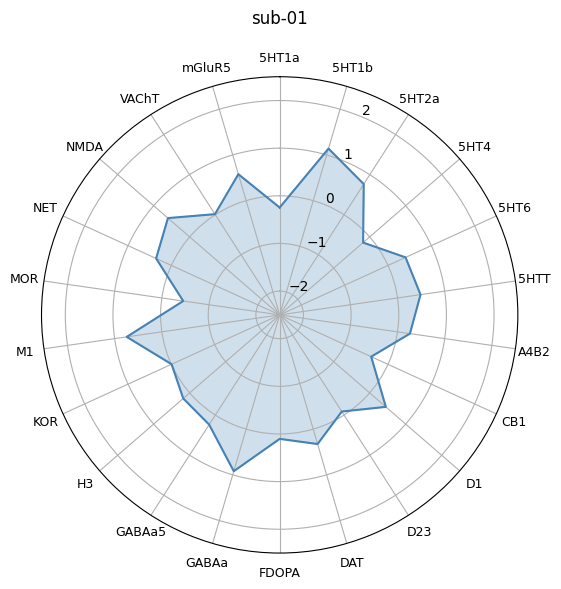

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tsv = next(Path("/tmp/outputs_lntf/sub-01/ses-01/anat").glob("*lntf*profilestats.tsv"))
df = pd.read_csv(tsv, sep="\t").sort_values("target")

targets = df["target"].tolist()
values = df["value"].to_numpy()
angles = np.linspace(0, 2 * np.pi, len(targets), endpoint=False)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection="polar"))
ax.plot(np.append(angles, angles[0]), np.append(values, values[0]),
        color="steelblue", linewidth=1.5)
ax.fill(np.append(angles, angles[0]), np.append(values, values[0]),
        color="steelblue", alpha=0.25)
ax.set_xticks(angles)
ax.set_xticklabels(targets, fontsize=9)
ax.set_ylim(-2.5, 2.5)
ax.set_yticks([-2, -1, 0, 1, 2])
ax.set_title("sub-01", pad=20)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
plt.tight_layout()
plt.show()


## Top neurotransmitter target overlaid on the lesion

Identify the highest-scoring target for sub-01 and plot the corresponding (z-scored) NT map with the lesion outline overlaid. The display is centred on the lesion centroid.

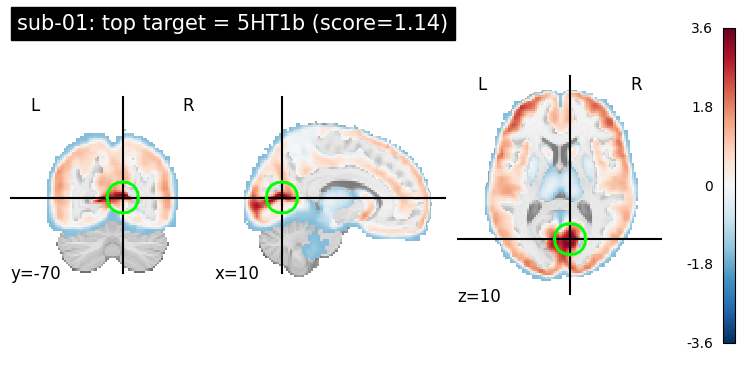

In [69]:
import nibabel as nib
import numpy as np
from nilearn import plotting
from pathlib import Path

scores = dict(zip(df["target"], df["value"]))
top_target = max(scores, key=scores.get)
nt_map = nib.load(Path("/tmp/ntatlas_data/maps") / f"{top_target}.nii.gz")
lesion_path = next(Path("/tmp/tutorial_bids/sub-01/ses-01/anat").glob("*mask*.nii.gz"))
lesion = nib.load(lesion_path)

coords = np.argwhere(lesion.get_fdata() > 0)
centroid_mm = (
    tuple(nib.affines.apply_affine(lesion.affine, coords.mean(axis=0)))
    if len(coords) else (0, 0, 0)
)

display = plotting.plot_stat_map(
    nt_map,
    display_mode="ortho",
    cut_coords=centroid_mm,
    title=f"sub-01: top target = {top_target} (score={scores[top_target]:.2f})",
    colorbar=True,
)
display.add_contours(str(lesion_path), levels=[0.5], colors="lime", linewidths=2)
plotting.show()
